<a href="https://colab.research.google.com/github/winter-pro/Statistical-Learning-e23091/blob/main/Assignment_7_Kalman_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Analytical Derivations & Summaries

Q1. Analytical Derivation Solutions

Time Update (Predictive Distribution):

Given $x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}$, where $x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathcal{N}(0, \Sigma_p)$. Because a linear combination of independent Gaussian random variables is also Gaussian, $x_k^-$ is Gaussian:$$m_k^- = \mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}] = A_{k-1}m_{k-1}$$$$P_k^- = \text{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}) = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

Measurement Prediction:

Given $y_k^- = H_k x_k^- + z_k$ where $z_k \sim \mathcal{N}(0, \Sigma_m)$:$$\mathbb{E}[y_k^-] = H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$$$\text{Var}(y_k^-) = H_k \text{Var}(x_k^-)H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

Joint Distribution:

The cross-covariance between $x_k^-$ and $y_k^-$ is:$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T] = P_k^- H_k^T$$Thus, the joint vector is distributed as:$$\begin{bmatrix} x_k^- \\ y_k \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}\right)$$

Measurement Update (Posterior):

Using the linear Gaussian conditioning rule on the joint distribution yields the standard Kalman filter measurement updates:$$K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$$$m_k = m_k^- + K_k(y_k^{\text{obs}} - H_k m_k^-)$$$$P_k = (I - K_k H_k)P_k^-$$

Part 2: Complete Google Colab Code
Copy and paste the code block below into a single cell in your Google Colab notebook to run the 1-D dynamic animation and the 2D Constant Velocity Position Filter.

--- Running Section 1: 1-D Kalman Filter Animation ---



--- Running Section 2: 2D Position Tracking (Constant Velocity Model) ---


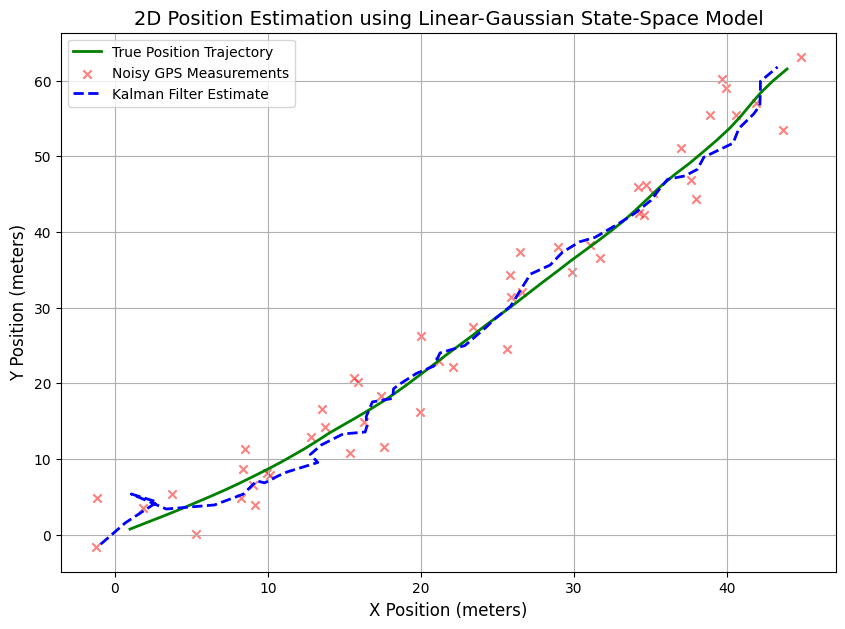

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.stats import norm
from IPython.display import HTML

# Ensure inline plots show up properly
%matplotlib inline

# ==========================================
# SECTION 1: Q. 1-D Example & Animation
# ==========================================
print("--- Running Section 1: 1-D Kalman Filter Animation ---")

# System Parameters
np.random.seed(42)
N_steps = 30
a = 0.95
h = 1.0
q = 0.2    # Process noise variance
r = 0.8    # Measurement noise variance

# True states and measurements initialization
x_true = np.zeros(N_steps)
y_obs = np.zeros(N_steps)
x_true[0] = np.random.normal(0, 1)

for k in range(1, N_steps):
    x_true[k] = a * x_true[k-1] + np.random.normal(0, np.sqrt(q))
    y_obs[k] = h * x_true[k] + np.random.normal(0, np.sqrt(r))
y_obs[0] = h * x_true[0] + np.random.normal(0, np.sqrt(r))

# Filter Arrays
m_prior_hist = np.zeros(N_steps)
P_prior_hist = np.zeros(N_steps)
m_post_hist = np.zeros(N_steps)
P_post_hist = np.zeros(N_steps)

# Prior initialization
m_post = 0.0
P_post = 1.0

for k in range(N_steps):
    # 1. Time Update (Predict)
    if k == 0:
        m_prior = m_post
        P_prior = P_post
    else:
        m_prior = a * m_post
        P_prior = (a**2) * P_post + q

    # 2. Measurement Update
    S = (h**2) * P_prior + r
    K = (P_prior * h) / S
    m_post = m_prior + K * (y_obs[k] - h * m_prior)
    P_post = (1 - K * h) * P_prior

    # Save histories
    m_prior_hist[k] = m_prior
    P_prior_hist[k] = P_prior
    m_post_hist[k] = m_post
    P_post_hist[k] = P_post

# Setup Animation Canvas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
x_axis = np.linspace(-5, 5, 500)

ax1.set_xlim(0, N_steps)
ax1.set_ylim(-6, 6)
ax1.set_xlabel('Time step (k)')
ax1.set_ylabel('State value')
ax1.grid(True)
line_true, = ax1.plot([], [], 'g-', label='True State', linewidth=2)
line_obs, = ax1.plot([], [], 'rx', label='Observations', markersize=6)
line_est, = ax1.plot([], [], 'b--', label='Estimated State (Posterior Mean)')
ax1.legend(loc='upper right')

line_prior_pdf, = ax2.plot([], [], 'r-', label='Prior Gaussian PDF')
line_post_pdf, = ax2.plot([], [], 'b-', label='Posterior Gaussian PDF')
ax2.set_xlim(-5, 5)
ax2.set_ylim(0, 1.5)
ax2.set_xlabel('State Domain')
ax2.set_ylabel('Probability Density')
ax2.grid(True)
ax2.legend(loc='upper right')
txt = ax2.text(0.05, 0.85, '', transform=ax2.transAxes, fontsize=12)

def init():
    line_true.set_data([], [])
    line_obs.set_data([], [])
    line_est.set_data([], [])
    line_prior_pdf.set_data([], [])
    line_post_pdf.set_data([], [])
    txt.set_text('')
    return line_true, line_obs, line_est, line_prior_pdf, line_post_pdf, txt

def animate(i):
    # Plot tracking histories up to frame i
    t = np.arange(i + 1)
    line_true.set_data(t, x_true[:i+1])
    line_obs.set_data(t, y_obs[:i+1])
    line_est.set_data(t, m_post_hist[:i+1])

    # Compute PDFs for current frame
    pdf_prior = norm.pdf(x_axis, m_prior_hist[i], np.sqrt(P_prior_hist[i]))
    pdf_post = norm.pdf(x_axis, m_post_hist[i], np.sqrt(P_post_hist[i]))

    line_prior_pdf.set_data(x_axis, pdf_prior)
    line_post_pdf.set_data(x_axis, pdf_post)

    txt.set_text(f'Time Step: {i}\nPrior Mean: {m_prior_hist[i]:.2f}\nPosterior Mean: {m_post_hist[i]:.2f}')
    return line_true, line_obs, line_est, line_prior_pdf, line_post_pdf, txt

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=N_steps, interval=400, blit=True)
plt.close()

# Render animation inside Google Colab cell
display(HTML(anim.to_jshtml()))


# ==========================================
# SECTION 2: Q. 2D-Position Estimation
# ==========================================
print("\n--- Running Section 2: 2D Position Tracking (Constant Velocity Model) ---")

dt = 0.5  # Time step delta_t
N_2d = 50

# Transition matrices defined exactly as given
A = np.array([[1, 0, dt,  0],
              [0, 1,  0, dt],
              [0, 0,  1,  0],
              [0, 0,  0,  1]])

H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]])

G = np.array([[0.5 * (dt**2), 0],
              [0, 0.5 * (dt**2)],
              [dt, 0],
              [0, dt]])

# Noise covariances
Sigma_p = np.array([[0.1, 0],
                    [0, 0.1]])  # Process noise acceleration covariance
Sigma_m = np.array([[4.0, 0],
                    [0, 4.0]])  # GPS measurement noise covariance

Q = G @ Sigma_p @ G.T
R = Sigma_m

# Generate True Trajectory and Noisy GPS Measurements
x_state = np.array([0.0, 0.0, 2.0, 1.5])  # initial position (0,0), velocity (2, 1.5)
true_positions = []
measured_positions = []

for k in range(N_2d):
    w = np.random.multivariate_normal([0, 0], Sigma_p)
    x_state = A @ x_state + G @ w
    z = np.random.multivariate_normal([0, 0], Sigma_m)
    y = H @ x_state + z

    true_positions.append((x_state[0], x_state[1]))
    measured_positions.append((y[0], y[1]))

true_positions = np.array(true_positions)
measured_positions = np.array(measured_positions)

# Run the 2D Kalman Filter
m_kf = np.array([0.0, 0.0, 0.0, 0.0])  # initial state guess
P_kf = np.eye(4) * 10.0               # initial state uncertainty
estimated_positions = []

for k in range(N_2d):
    # Predict
    m_kf_minus = A @ m_kf
    P_kf_minus = A @ P_kf @ A.T + Q

    # Update
    S = H @ P_kf_minus @ H.T + R
    K = P_kf_minus @ H.T @ np.linalg.inv(S)

    y_obs_curr = measured_positions[k]
    m_kf = m_kf_minus + K @ (y_obs_curr - H @ m_kf_minus)
    P_kf = (np.eye(4) - K @ H) @ P_kf_minus

    estimated_positions.append((m_kf[0], m_kf[1]))

estimated_positions = np.array(estimated_positions)

# Plotting 2D Filtering Results
plt.figure(figsize=(10, 7))
plt.plot(true_positions[:, 0], true_positions[:, 1], 'g-', label='True Position Trajectory', linewidth=2)
plt.scatter(measured_positions[:, 0], measured_positions[:, 1], color='red', alpha=0.5, marker='x', label='Noisy GPS Measurements')
plt.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'b--', label='Kalman Filter Estimate', linewidth=2)
plt.title('2D Position Estimation using Linear-Gaussian State-Space Model', fontsize=14)
plt.xlabel('X Position (meters)', fontsize=12)
plt.ylabel('Y Position (meters)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()